# MV-4571 — EP imbalance theo TIME (torch profiler traces, 8 rank)

Self-contained: **Bước 0** verify schema → **Bước 1** parse 8 trace (comm-bounded) →
verify cùng-kernel → phân loại phase theo kernel → phân tích & vẽ. Output vào
`logs/<run_ts>_<scenario>/`. Tài liệu: `events.MD`, `MOE_DATA_FLOW.md`, `TRACE_TIME_ANALYSIS.md`.

**3 struct** (định nghĩa & comment field ở Bước 1): `Region` (1 cụm/1 rank), `Clusters`
(8 rank đã căn theo cụm), `Metrics` (chỉ số imbalance/cụm); + enum `Phase` (prefill/decode).

## Bước 0 — VERIFY schema trace (xác minh giả định; có thể bỏ qua)
Mỗi cell stream 1 file `.pt.trace.json.gz` (~1–2 phút) bằng `ijson` (KHÔNG `json.load` → OOM).

In [4]:
# CHECK-0 — config + helper cho phần verify.
import os, glob, gzip, re, collections
import ijson
# TRACE_DIR = thư mục chứa 8 file trace gz (1 file / rank: dp<r>_..._rank0.*.pt.trace.json.gz)
TRACE_DIR = "/home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_profile/20260625_091838/profiling_result/run1/8k_rinf_c8"
FILES = sorted(glob.glob(os.path.join(TRACE_DIR, "dp*_rank0.*.pt.trace.json.gz")))
def iter_events(path):
    # stream từng phần tử traceEvents[] (không nạp cả file ~7M event vào RAM)
    with gzip.open(path, "rb") as fh:
        yield from ijson.items(fh, "traceEvents.item")
def rank_of(path):
    return int(re.search(r"dp(\d+)_", os.path.basename(path)).group(1))   # số DP-rank từ tên file
print(len(FILES), "trace files:")
for f in FILES: print("  ", os.path.basename(f))

8 trace files:
   dp0_pp0_tp0_dcp0_ep0_rank0.1782379578920175981.pt.trace.json.gz
   dp1_pp0_tp0_dcp0_ep1_rank0.1782379579092325349.pt.trace.json.gz
   dp2_pp0_tp0_dcp0_ep2_rank0.1782379580050704025.pt.trace.json.gz
   dp3_pp0_tp0_dcp0_ep3_rank0.1782379580437021538.pt.trace.json.gz
   dp4_pp0_tp0_dcp0_ep4_rank0.1782379578968845020.pt.trace.json.gz
   dp5_pp0_tp0_dcp0_ep5_rank0.1782379578090377256.pt.trace.json.gz
   dp6_pp0_tp0_dcp0_ep6_rank0.1782379578236205814.pt.trace.json.gz
   dp7_pp0_tp0_dcp0_ep7_rank0.1782379579255000427.pt.trace.json.gz


In [5]:
# CHECK-1 — in ~900 byte đầu = header top-level (schemaVersion / deviceProperties / traceEvents).
with gzip.open(FILES[0], "rb") as fh:
    print(fh.read(900).decode("utf-8", "ignore"))


  {
    "schemaVersion": 1,
    "deviceProperties": [
    {
      "id": 0, "name": "", "totalGlobalMem": 206141652992,
      "computeMajor": 9, "computeMinor": 4,
      "maxThreadsPerBlock": 1024, "maxThreadsPerMultiprocessor": 2048,
      "regsPerBlock": 131072, "warpSize": 64,
      "sharedMemPerBlock": 65536, "numSms": 304
    , "maxSharedMemoryPerMultiProcessor": 65536
    },
    {
      "id": 1, "name": "", "totalGlobalMem": 206141652992,
      "computeMajor": 9, "computeMinor": 4,
      "maxThreadsPerBlock": 1024, "maxThreadsPerMultiprocessor": 2048,
      "regsPerBlock": 131072, "warpSize": 64,
      "sharedMemPerBlock": 65536, "numSms": 304
    , "maxSharedMemoryPerMultiProcessor": 65536
    },
    {
      "id": 2, "name": "", "totalGlobalMem": 206141652992,
      "computeMajor": 9, "computeMinor": 4,
      "maxThreadsPerBlock": 1024, "maxThreadsPerMultiprocessor": 2048,
      "


In [6]:
# CHECK-2 — quét rank0 (toàn file): phân bố cat/ph, đếm kernel MoE, comm variants, đơn vị µs.
def cls(n):                                   # phân loại 1 kernel theo tên
    if "ncclDevKernel" in n: return "comm"
    if "MoeSorting" in n: return "sort"
    if "dynamic_per_group_scaled_quant" in n: return "quant"
    if "kernel_moe_gemm" in n: return "gemm1" if "(ck::InMemoryDataOperationEnum)0" in n else "gemm2"
    if "fmoe" in n: return "fmoe"
    return None
cat = collections.Counter(); ph = collections.Counter(); kc = collections.Counter()
comm_names = collections.Counter(); gemm_dur = None
for e in iter_events(FILES[0]):
    cat[e.get("cat")] += 1; ph[e.get("ph")] += 1
    if e.get("cat") == "kernel":
        n = e.get("name", ""); c = cls(n)
        if c: kc[c] += 1
        if c == "comm": comm_names[n] += 1
        if c == "gemm1" and gemm_dur is None: gemm_dur = float(e["dur"])
print("cat :", dict(cat))
print("ph  :", dict(ph), " -> chỉ 'X' có dur (ta dùng); s/f=flow, M=metadata, i=instant")
print("kernel MoE classes:", dict(kc))
print("comm name variants:", dict(comm_names), "-> 1 TÊN => KHÔNG phân biệt gather/rs bằng tên")
print("gemm stage1 dur =", gemm_dur, "us -> xác nhận ts/dur là µs")
print("gemm1+gemm2+2*fmoe =", kc.get("gemm1",0)+kc.get("gemm2",0)+2*kc.get("fmoe",0),
      "vs comm =", kc.get("comm"), " -> mỗi cụm = 1 gather + 1 reduce-scatter (2 comm)")

cat : {'user_annotation': 2753, 'cpu_op': 409600, 'cuda_runtime': 161533, 'ac2g': 3363829, 'gpu_memcpy': 8458, 'kernel': 3193838, 'gpu_user_annotation': 1720, None: 66, 'Trace': 1}
ph  : {'X': 3777903, 's': 61798, 'f': 3302031, 'M': 64, 'i': 2}  -> chỉ 'X' có dur (ta dùng); s/f=flow, M=metadata, i=instant
kernel MoE classes: {'quant': 231750, 'comm': 154650, 'sort': 78000, 'fmoe': 225, 'gemm1': 77100, 'gemm2': 77100}
comm name variants: {'ncclDevKernel_Generic_2(ncclDevKernelArgsStorage<4096ul>)': 154650} -> 1 TÊN => KHÔNG phân biệt gather/rs bằng tên
gemm stage1 dur = 32.007 us -> xác nhận ts/dur là µs
gemm1+gemm2+2*fmoe = 154650 vs comm = 154650  -> mỗi cụm = 1 gather + 1 reduce-scatter (2 comm)


In [7]:
# CHECK-3 — clock CHUNG giữa rank? So [ts_min, ts_max] rank0 vs rank1.
def ts_range(path):
    lo = float("inf"); hi = -1.0
    for e in iter_events(path):
        if e.get("cat") != "kernel": continue
        t = float(e["ts"]); lo = min(lo, t); hi = max(hi, t)
    return lo, hi
a = ts_range(FILES[0]); b = ts_range(FILES[1])
print("rank0 ts range:", a); print("rank1 ts range:", b)
print("offset(min) ms =", (b[0]-a[0])/1e3, " overlap =", not (a[1] < b[0] or b[1] < a[0]))
print("-> lệch ~0 & overlap => clock CHUNG, so timestamp giữa rank hợp lệ")

rank0 ts range: (7300941491541.35, 7301017446847.436)
rank1 ts range: (7300941489050.344, 7301017446847.144)
offset(min) ms = -2.491005859375  overlap = True
-> lệch ~0 & overlap => clock CHUNG, so timestamp giữa rank hợp lệ


In [8]:
# CHECK-4 (CHẬM ~vài phút, ĐỦ 8 file) — MAPPING: #comm bằng nhau giữa các rank?
ncomm = {}
for f in FILES:
    r = rank_of(f)
    ncomm[r] = sum(1 for e in iter_events(f)
                   if e.get("cat") == "kernel" and "ncclDevKernel" in e.get("name", ""))
    print(f"rank{r}: #comm={ncomm[r]}")
print("=>", "BẰNG NHAU (map 1-1 giữa rank)" if len(set(ncomm.values())) == 1 else "KHÁC NHAU!")

rank0: #comm=154650
rank1: #comm=154650
rank2: #comm=154650
rank3: #comm=154650
rank4: #comm=154650
rank5: #comm=154650
rank6: #comm=154650
rank7: #comm=154650
=> BẰNG NHAU (map 1-1 giữa rank)


## Bước 1 — PARSE traces (comm-bounded) + định nghĩa struct
MoE bị kẹp giữa 2 collective: `gather → [sort/quant/gemm/fmoe] → reduce-scatter`. Đo
MoE-time/cụm = `reduce_scatter.start − gather.end` (độc lập kiểu kernel). Phân biệt gather/rs
bằng **vị trí** (comm trước cụm = gather, comm sau = reduce-scatter).

Định nghĩa **`Region`** (numpy record, 1 cụm/1 rank), **`Clusters`** (8 rank căn theo cụm),
**`Metrics`** (chỉ số/cụm), enum **`Phase`** — tất cả có comment field.

In [ ]:
# ---- CONFIG parse ----
import os, glob, gzip, re, json, collections
from dataclasses import dataclass
from enum import Enum
import numpy as np
import ijson
import matplotlib.pyplot as plt

TRACE_DIR = "/home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_profile/20260625_091838/profiling_result/run1/8k_rinf_c8"
DROP_HEAD = 0     # bỏ số cụm ĐẦU (warmup/startup: comm khổng lồ, gây nhiễu)

def _derive_out(td):
    # .../auto_profile/<run_ts>/profiling_result/run1/<scenario>  ->  ./logs/<run_ts>_<scenario>
    parts = td.rstrip("/").split("/"); scenario = parts[-1]
    runts = parts[parts.index("profiling_result")-1] if "profiling_result" in parts else ""
    return os.path.join(os.getcwd(), "logs", f"{runts}_{scenario}" if runts else scenario)
OUT = _derive_out(TRACE_DIR); os.makedirs(OUT, exist_ok=True)
FILES = sorted(glob.glob(os.path.join(TRACE_DIR, "dp*_rank0.*.pt.trace.json.gz")))
def iter_events(path):
    with gzip.open(path, "rb") as fh:
        yield from ijson.items(fh, "traceEvents.item")
def rank_of(p): return int(re.search(r"dp(\d+)_", os.path.basename(p)).group(1))
print("TRACE_DIR =", TRACE_DIR); print("OUT       =", OUT); print(len(FILES), "files")

TRACE_DIR = /home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/auto_profile/20260625_091838/profiling_result/run1/8k_rinf_c8
OUT       = /home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/EP_imbalance_analysis/logs/20260625_091838_8k_rinf_c8
8 files


In [ ]:
# =====================================================================
# STRUCT 1 (Region) + STRUCT 2 (Clusters) + enum Phase, gộp 1 cell.
# Parse 8 rank (KHÔNG cache — luôn chạy lại từ đầu) -> C; tính phase luôn ở đây.
# Dùng struct ngay khi parse để dễ phân biệt field.
# =====================================================================

# ----- Region: 1 cụm MoE trên 1 RANK (numpy record; ts đơn vị µs) -----
REGION_DT = np.dtype([
    ("gather_start", "f8"), ("gather_end", "f8"),  # gather: bắt đầu / KẾT THÚC (-> MoE bắt đầu)
    ("moe_start",    "f8"), ("moe_end",    "f8"),  # kernel MoE đầu tiên / cuối cùng
    ("rs_start",     "f8"), ("rs_end",     "f8"),  # reduce-scatter: BẮT ĐẦU (-> MoE kết thúc) / kết thúc
    ("nstage",       "i4"), ("sig",        "i8"),  # #kernel matmul (1=fused/2=two-stage) ; id chữ ký kernel
    ("moe_busy",     "f8"),                        # tổng DUR kernel MoE (sort+gemm+fmoe) = perfetto "MoE"
])

# ----- enum Phase -----
class Phase(str, Enum):
    PREFILL = "prefill"   # 1 kernel matmul (fused fmoe) — chunk lớn, MoE-time lớn
    DECODE  = "decode"    # 2 kernel matmul (gemm1 + gemm2) — ít token, MoE-time nhỏ

# ----- phân loại kernel theo tên -----
def is_comm(n): return "ncclDevKernel" in n
def moe_kind(n):
    # "kind" của kernel MoE-compute (None nếu không phải opener, vd quant)
    if "MoeSortingClearWorkspace" in n: return "sortClear"
    if "MoeSortingMultiPhase"     in n: return "sortMP"
    if "MoeSorting"               in n: return "sort"
    if "kernel_moe_gemm" in n: return "gemm1" if "(ck::InMemoryDataOperationEnum)0" in n else "gemm2"
    if "fmoe" in n: return "fmoe"
    return None
MATMUL = {"gemm1", "gemm2", "fmoe"}          # kernel matmul thực sự (đếm nstage)
_SIG = {}                                     # registry: tuple(kind...) -> id (so giữa rank)
def _sig_id(kinds):
    t = tuple(kinds)
    if t not in _SIG: _SIG[t] = len(_SIG)
    return _SIG[t]

def parse_rank_pairs(path):
    """Parse 1 rank -> np.ndarray[Region]. Dùng dict `cur` đặt field theo TÊN cho dễ đọc:
    opener đầu tiên MỞ cụm (gather = comm liền trước); comm kế tiếp ĐÓNG cụm (= reduce-scatter)."""
    comm, opn = [], []
    for e in iter_events(path):
        if e.get("ph") != "X" or e.get("cat") != "kernel": continue   # chỉ kernel GPU có dur
        ts = e.get("ts"); dur = e.get("dur"); n = e.get("name", "")
        if ts is None or dur is None: continue
        ts = float(ts); end = ts + float(dur)
        if is_comm(n):
            comm.append((ts, end, "c", None))
        else:
            k = moe_kind(n)
            if k is not None: opn.append((ts, end, "o", k))           # opener; bỏ quant & kernel khác
    evs = sorted(comm + opn, key=lambda x: x[0])                      # 2 stream -> 1 timeline

    regs, last, cur = [], None, None     # last = comm gần nhất (ứng viên gather); cur = cụm đang mở
    for ts, end, typ, k in evs:
        if typ == "o":                   # kernel MoE
            if cur is None:              # opener ĐẦU TIÊN -> mở cụm; gather = comm liền trước
                if last is None:
                    raise Exception("No previous communication event found for the first opener")
                gs, ge = last
                cur = {"gather_start": gs, "gather_end": ge, "moe_start": ts, "moe_end": end, "kinds": [k], "busy": end - ts}
            else:                        # opener tiếp theo -> nới moe_end, ghi kind
                if end > cur["moe_end"]: 
                    cur["moe_end"] = end
                else:
                    raise Exception("Opener end time is earlier than current moe_end")
                cur["kinds"].append(k); cur["busy"] += end - ts   # cộng dur kernel vào MoE-busy
        else:                            # comm -> nếu đang mở cụm thì đây là reduce-scatter (đóng cụm)
            if cur is not None:
                regs.append((cur["gather_start"], cur["gather_end"], cur["moe_start"], cur["moe_end"],
                             ts, end, int(sum(x in MATMUL for x in cur["kinds"])), _sig_id(cur["kinds"]), cur["busy"]))
                cur = None
            last = (ts, end)
    return np.array(regs, dtype=REGION_DT)

# ----- Clusters: 8 rank ĐÃ CĂN theo cụm (struct-of-arrays); field = ma trận (R, K) -----
@dataclass
class Clusters:
    ranks:        np.ndarray   # (R,)   id các rank
    gather_start: np.ndarray   # (R,K)  ts bắt đầu gather
    gather_end:   np.ndarray   # (R,K)  ts kết thúc gather  -> MỐC MoE bắt đầu
    rs_start:     np.ndarray   # (R,K)  ts bắt đầu reduce-scatter -> MỐC MoE kết thúc
    rs_end:       np.ndarray   # (R,K)  ts kết thúc reduce-scatter (barrier)
    nstage:       np.ndarray   # (R,K)  1=fused/prefill, 2=two-stage/decode
    sig:          np.ndarray   # (R,K)  id chữ ký chuỗi kernel MoE
    moe_busy:     np.ndarray   # (R,K)  tổng dur kernel MoE/cụm (sort+gemm+fmoe) = "MoE" kiểu perfetto
    @property
    def moe(self):        return self.rs_start - self.gather_end       # (R,K) MoE-compute time (µs)
    @property
    def gather_dur(self): return self.gather_end - self.gather_start   # (R,K)
    @property
    def rs_dur(self):     return self.rs_end - self.rs_start           # (R,K)
    @property
    def shape(self):      return self.moe.shape                        # (R, K)

# ----- parse 8 rank (no cache) -> dựng C -----
reg = {}
for f in FILES:
    r = rank_of(f); reg[r] = parse_rank_pairs(f)
    print(f"  rank{r}: regions={len(reg[r]):7d}")
ranks = sorted(reg); 
K = min(len(reg[r]) for r in ranks)              # căn theo rank ít cụm nhất
def field(name): 
    return np.stack([reg[r][name][:K] for r in ranks])[:, DROP_HEAD:]   # (R,K) bỏ head

C = Clusters(ranks=np.array(ranks),
             gather_start=field("gather_start"), gather_end=field("gather_end"),
             rs_start=field("rs_start"), rs_end=field("rs_end"),
             nstage=field("nstage"), sig=field("sig"), moe_busy=field("moe_busy"))
R, K = C.shape
np.savez_compressed(os.path.join(OUT, "trace_pairs.npz"), ranks=C.ranks, MOE=C.moe,
                    GS=C.gather_start, GE=C.gather_end, RSs=C.rs_start, RSe=C.rs_end,
                    NSTAGE=C.nstage, SIG=C.sig, MOE_BUSY=C.moe_busy)

# ----- phase theo kernel (đặt LUÔN ở đây) -----
nst0 = C.nstage[0]                                                     # nstage/cụm (đồng nhất giữa rank)
phase = np.where(nst0 == 1, Phase.PREFILL.value, Phase.DECODE.value)   # 1->prefill, 2->decode
pre = phase == Phase.PREFILL.value; dec = phase == Phase.DECODE.value  # mask (np cần .value)
print(f"ranks={list(C.ranks)}  R={R}  clusters K={K}  MoE-time median={np.median(C.moe):.1f}us")
print("phase:", {"prefill(1-kernel)": int(pre.sum()), "decode(2-kernel)": int(dec.sum())})


  rank0: regions=  77325


## 1b. VERIFY — mỗi cụm (8 rank) gọi CÙNG kernel MoE
Kiểm tra `sig` & `nstage` **giống nhau giữa 8 rank** ở mọi cụm → cùng 1 dãy kernel (sorting + gemm/fmoe).

In [ ]:
sig_same = (C.sig    == C.sig[0]).all(axis=0)      # (K,) True nếu 8 rank cùng chữ ký kernel
nst_same = (C.nstage == C.nstage[0]).all(axis=0)
print(f"clusters K = {K}")
print(f"  sig    giống nhau cả 8 rank: {sig_same.sum()}/{K}  ({100*sig_same.mean():.2f}%)")
print(f"  nstage giống nhau cả 8 rank: {nst_same.sum()}/{K}  ({100*nst_same.mean():.2f}%)")
id2sig = {v: k for k, v in _SIG.items()} if _SIG else {}     # giải mã (rỗng nếu load cache)
print("\nTop chữ ký (sig id -> chuỗi kind kernel : số cụm):")
for sid, cnt in collections.Counter(C.sig[0].tolist()).most_common(6):
    print(f"  id={sid}  x{cnt:6d}  {id2sig.get(sid, '(cache: parse lại để xem chuỗi)')}")
print("\nOK: mọi cụm 8 rank cùng kernel." if sig_same.all() else
      "Có cụm khác chữ ký: " + str(np.where(~sig_same)[0][:5].tolist()))

clusters K = 77261
  sig    giống nhau cả 8 rank: 77261/77261  (100.00%)
  nstage giống nhau cả 8 rank: 77261/77261  (100.00%)

Top chữ ký (sig id -> chuỗi kind kernel : số cụm):
  id=1  x 77100  ('sort', 'gemm1', 'gemm2')
  id=0  x   161  ('sortClear', 'sortMP', 'sortMP', 'sortMP', 'fmoe')

OK: mọi cụm 8 rank cùng kernel.


## 1c. Phân loại phase theo KERNEL (enum `Phase`, bỏ ngưỡng cảm quan)
1 kernel matmul (fused `fmoe`) → **prefill**; 2 kernel (`gemm1`+`gemm2`) → **decode**.
3 xác nhận: (1) 8 rank cùng kernel, (2) gán nhãn theo nstage, (3) `time(prefill) > time(decode)`.

In [ ]:
# 3 XÁC NHẬN cách chia phase (phase/pre/dec đã tính ở cell parse):
mt = C.moe.mean(0)                                                # MoE-time tb/cụm
print(f"{mt.shape=}, {mt[pre].shape=}, {mt[dec].shape=}")
med_pre = float(np.median(mt[pre])) if pre.any() else float("nan")
med_dec = float(np.median(mt[dec])) if dec.any() else float("nan")
c1 = bool((C.nstage == C.nstage[0]).all() and (C.sig == C.sig[0]).all())   # (1) 8 rank cùng kernel
c3 = med_pre > med_dec                                                      # (3) prefill chậm hơn decode
print("phase counts:", {"prefill(1-kernel)": int(pre.sum()), "decode(2-kernel)": int(dec.sum())})
print(f"  prefill (1 kernel/fmoe): MoE-time median = {med_pre:8.1f} us")
print(f"  decode  (2 kernel/gemm): MoE-time median = {med_dec:8.1f} us")
print("\nXÁC NHẬN cách chia phase:")
print(f"  (1) 8 rank/cụm cùng kernel (nstage+sig đồng nhất): {'OK' if c1 else 'FAIL'}")
print(f"  (2) nhãn: 1 stage -> prefill, 2 stage -> decode")
print(f"  (3) time(prefill) > time(decode): {'OK' if c3 else 'FAIL'}  ({med_pre:.0f} > {med_dec:.0f} us)")
assert c1 and c3, "Xác nhận phase THẤT BẠI"
print("=> cách chia phase theo kernel ĐÚNG.")


mt.shape=(77261,), mt[pre].shape=(161,), mt[dec].shape=(77100,)
phase counts: {'prefill(1-kernel)': 161, 'decode(2-kernel)': 77100}
  prefill (1 kernel/fmoe): MoE-time median =   2763.2 us
  decode  (2 kernel/gemm): MoE-time median =     95.7 us

XÁC NHẬN cách chia phase:
  (1) 8 rank/cụm cùng kernel (nstage+sig đồng nhất): OK
  (2) nhãn: 1 stage -> prefill, 2 stage -> decode
  (3) time(prefill) > time(decode): OK  (2763 > 96 us)
=> cách chia phase theo kernel ĐÚNG.


rank  MoE_busy  MoE_span    gather     rscat      comm      total   (ms)
   0    7180.9    7937.6   12391.8   15625.7   28017.5    35198.4
   1    7073.3    7833.8   11864.1   15136.9   27001.0    34074.2
   2    7184.0    7950.4   11905.2   14430.9   26336.1    33520.1
   3    7073.6    7834.9   12820.2   14001.7   26821.9    33895.6
   4    7093.3    7894.8   12056.8   14660.6   26717.4    33810.7
   5    7122.3    7916.4   13675.8   14984.4   28660.1    35782.4
   6    7061.8    7844.5   13186.0   15705.4   28891.3    35953.1
   7    7201.2    7988.9   11972.8   16069.7   28042.5    35243.7
mean    7123.8    7900.2   12484.1   15076.9   27561.0   34684.8
 max    7201.2    7988.9   13675.8   16069.7   28891.3   35953.1

(comm = full nccl sum; perfetto thấp hơn ~1.6K/rank do drop ~35 nccl chồng-lấp; MoE_busy ≈ perfetto 'MoE'.)


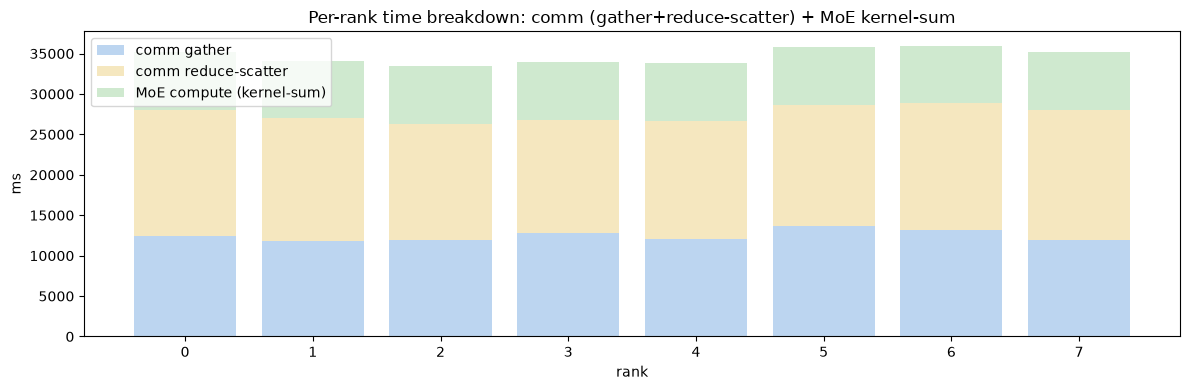

In [ ]:
# Bảng theo RANK (ms).
#   MoE_busy = tổng DUR kernel MoE (sort+gemm+fmoe) -> KHỚP "MoE" perfetto (~7.4K; KHÔNG gồm quant).
#   MoE_span = wall gather.end->rs.start (gồm gap rảnh) -> dùng critical-path (lớn hơn).
#   comm     = gather + reduce-scatter = TỔNG mọi nccl/rank (mỗi nccl đúng 1 lần — đã verify, không double-count).
#              ~1.6K CAO HƠN perfetto vì perfetto DROP ~35 slice nccl chồng-lấp trên track tid=4 (giới hạn render).
per_rank = []
for i in range(R):
    g   = float(C.gather_dur[i].sum()) / 1e3      # gather
    rs  = float(C.rs_dur[i].sum())     / 1e3      # reduce-scatter
    mb  = float(C.moe_busy[i].sum())   / 1e3      # MoE kernel-sum
    msp = float(C.moe[i].sum())        / 1e3      # MoE wall-span
    per_rank.append((int(C.ranks[i]), mb, msp, g, rs, g + rs, mb + g + rs))
print(f"{'rank':>4} {'MoE_busy':>9} {'MoE_span':>9} {'gather':>9} {'rscat':>9} {'comm':>9} {'total':>10}   (ms)")
for r, mb, msp, g, rs, ct, tot in per_rank:
    print(f"{r:>4} {mb:9.1f} {msp:9.1f} {g:9.1f} {rs:9.1f} {ct:9.1f} {tot:10.1f}")
A = np.array([[mb, msp, g, rs, ct, tot] for _, mb, msp, g, rs, ct, tot in per_rank])
print(f"{'mean':>4} " + " ".join(f"{v:9.1f}" for v in A.mean(0)))
print(f"{'max':>4} " + " ".join(f"{v:9.1f}" for v in A.max(0)))
print("\n(comm = full nccl sum; perfetto thấp hơn ~1.6K/rank do drop ~35 nccl chồng-lấp; MoE_busy ≈ perfetto 'MoE'.)")
labels = [str(r) for r, *_ in per_rank]; mm, gg, ss = A[:, 0], A[:, 2], A[:, 3]
plt.figure(figsize=(12, 4))
plt.bar(labels, gg, label="comm gather", color="#bcd5f0")
plt.bar(labels, ss, bottom=gg, label="comm reduce-scatter", color="#f5e7bf")
plt.bar(labels, mm, bottom=gg + ss, label="MoE compute (kernel-sum)", color="#cfe9cf")
plt.ylabel("ms"); plt.xlabel("rank"); plt.legend()
plt.title("Per-rank time breakdown: comm (gather+reduce-scatter) + MoE kernel-sum")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "per_rank_time_breakdown.png"), dpi=130); plt.show()


## 2. Chỉ số imbalance/cụm — struct `Metrics`

In [14]:
# =====================================================================
# STRUCT 3 — Metrics: chỉ số imbalance THEO TỪNG CỤM (vector dài K).
# =====================================================================
@dataclass
class Metrics:
    cmax:       np.ndarray   # (K,) MAX MoE-time qua 8 rank (rank chậm nhất = critical path)
    cmin:       np.ndarray   # (K,) MIN ...
    cmean:      np.ndarray   # (K,) MEAN ... (= tải nếu cân bằng hoàn hảo)
    imb_maxmin: np.ndarray   # (K,) cmax/cmin  (mức lệch max/min)
    imb_maxavg: np.ndarray   # (K,) cmax/cmean (room-for-improvement)
    comm:       np.ndarray   # (K,) comm tb/cụm (gather_dur + rs_dur)

moe = C.moe                                          # (R,K) cho gọn
MET = Metrics(
    cmax=moe.max(0), cmin=np.maximum(moe.min(0), 1e-9), cmean=moe.mean(0),
    imb_maxmin=moe.max(0) / np.maximum(moe.min(0), 1e-9),
    imb_maxavg=moe.max(0) / moe.mean(0),
    comm=C.gather_dur.mean(0) + C.rs_dur.mean(0),
)
print(f"MoE-time/cụm (us): median={np.median(moe):.1f} p99={np.percentile(moe,99):.1f}")
print(f"max/min: mean={MET.imb_maxmin.mean():.2f} median={np.median(MET.imb_maxmin):.2f} "
      f"p99={np.percentile(MET.imb_maxmin,99):.2f}")

MoE-time/cụm (us): median=94.8 p99=140.2
max/min: mean=1.73 median=1.68 p99=2.47


## 2b. Tổng thời gian theo từng RANK — MoE / comm(gather, reduce-scatter, total)
Cộng qua tất cả cụm (đã bỏ DROP_HEAD). Đơn vị ms. `comm` ở đây là thời lượng collective
của CHÍNH rank đó (gather_dur, rs_dur).

## 3. Phân phối imbalance max/min (TIME) — all / prefill / decode

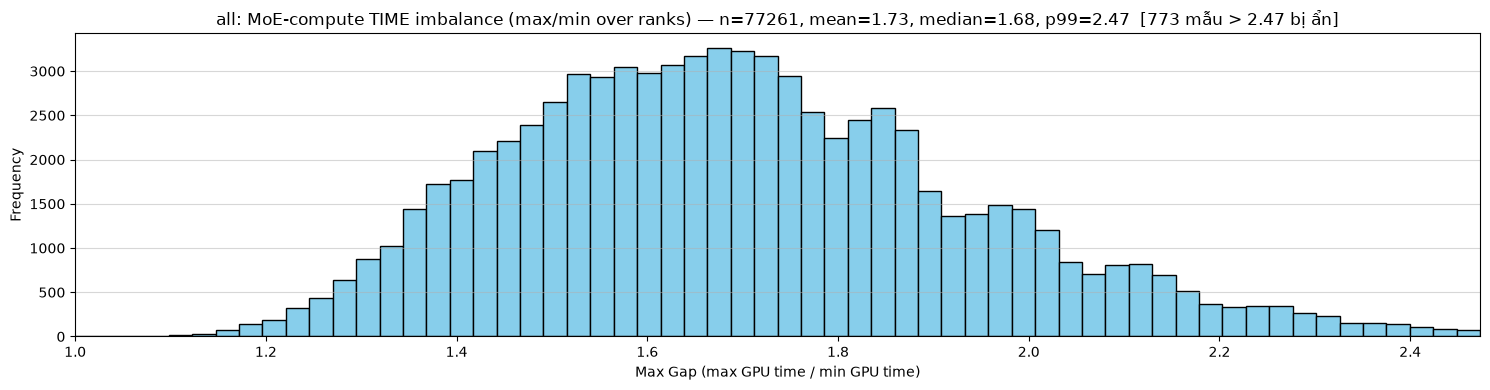

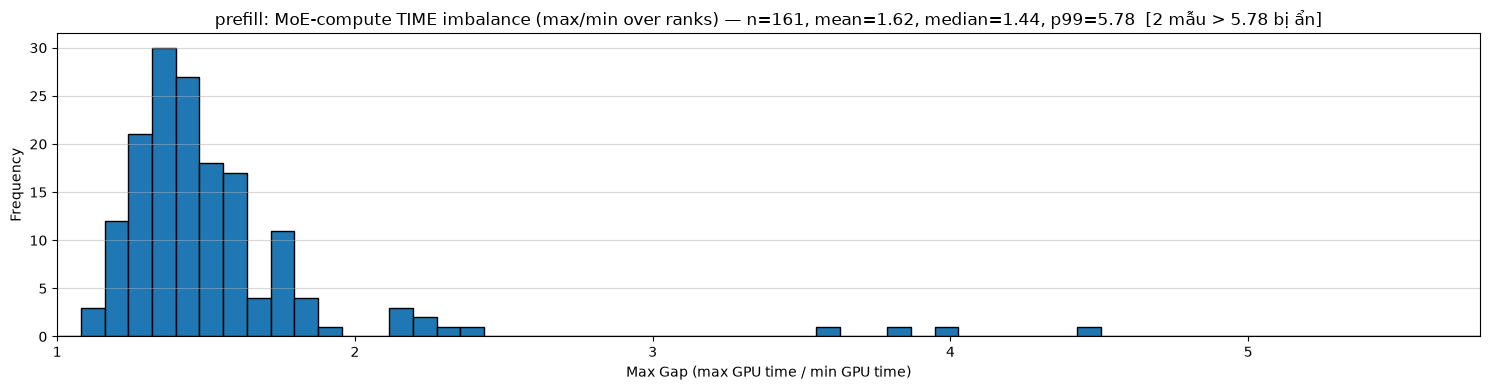

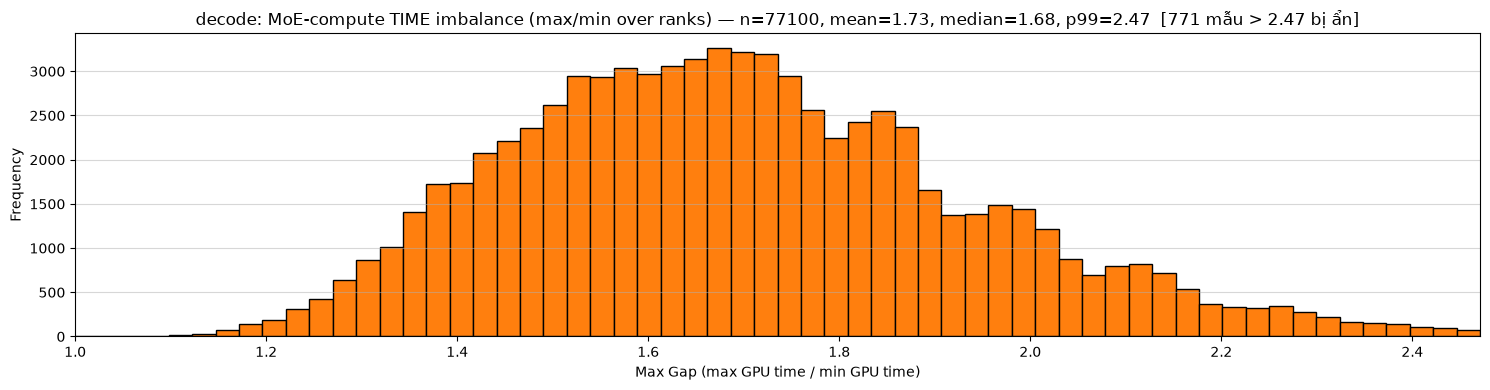

In [15]:
# 3 histogram phân phối max/min (TIME). range=(1,xmax) BỎ đuôi >xmax (tránh spike giả ở bin cuối).
for name, mask, color in [("all", np.ones(K, bool), "skyblue"),
                          (Phase.PREFILL.value, pre, "#1f77b4"), (Phase.DECODE.value, dec, "#ff7f0e")]:
    vals = MET.imb_maxmin[mask]
    if len(vals) == 0:
        print(f"{name}: (none)"); continue
    xmax = max(2.0, float(np.percentile(vals, 99)))
    n_over = int((vals > xmax).sum())          # số mẫu ĐUÔI (>xmax) -> bị ẩn (KHÔNG dồn vào bin cuối)
    plt.figure(figsize=(15, 4))
    plt.hist(vals, bins=60, range=(1, xmax), color=color, edgecolor="black")   # range -> bỏ đuôi, không clip
    plt.xlim(1, xmax)
    plt.title(f"{name}: MoE-compute TIME imbalance (max/min over ranks) — n={len(vals)}, "
              f"mean={vals.mean():.2f}, median={np.median(vals):.2f}, p99={np.percentile(vals,99):.2f}  "
              f"[{n_over} mẫu > {xmax:.2f} bị ẩn]")
    plt.xlabel("Max Gap (max GPU time / min GPU time)"); plt.ylabel("Frequency"); plt.grid(axis="y", alpha=.5)
    plt.tight_layout(); plt.savefig(os.path.join(OUT, f"time_imbalance_hist_{name}.png"), dpi=130); plt.show()


## 4. Imbalance theo cluster + tải per-rank + budget comm-vs-MoE

In [ ]:
def smooth(x, w=200):                       # moving-average cho đỡ nhiễu (chỉ để nhìn xu hướng)
    x = np.asarray(x, float); return np.convolve(x, np.ones(w)/w, mode="same")

# (a) MoE-time & imbalance theo cluster index (mượt)
fig, ax = plt.subplots(2, 1, figsize=(15, 8))
ax[0].plot(smooth(MET.cmean), color="#2ca02c", label="mean over ranks")
ax[0].plot(smooth(MET.cmax),  color="#d62728", alpha=.6, label="max over ranks (critical)")
ax[0].set_title("MoE-compute time per cluster (smoothed)"); ax[0].set_ylabel("us"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(smooth(MET.imb_maxmin), color="#9467bd")
ax[1].set_title("Per-cluster TIME imbalance max/min (smoothed)"); ax[1].set_xlabel("cluster index"); ax[1].set_ylabel("max/min"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT, "time_over_clusters.png"), dpi=130); plt.show()

# (b) tải tổng/rank + budget: comm vs MoE(critical=Σmax) vs MoE(balanced=Σmean)
tot_moe = C.moe.sum(1) / 1e3                  # ms / rank
crit = MET.cmax.sum()/1e3; bal = MET.cmean.sum()/1e3; comm_tot = MET.comm.sum()/1e3
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(range(R), tot_moe, color="#2ca02c"); ax[0].axhline(tot_moe.mean(), color="k", ls="--", label=f"mean={tot_moe.mean():.0f}ms")
ax[0].set_title(f"Per-rank total MoE-compute (max/min={tot_moe.max()/tot_moe.min():.3f})")
ax[0].set_xticks(range(R)); ax[0].set_xticklabels(C.ranks); ax[0].set_ylabel("ms"); ax[0].legend()
ax[1].bar(["comm\n(gather+rs)", "MoE crit\n(Σmax)", "MoE bal\n(Σmean)"], [comm_tot, crit, bal],
          color=["#f5e7bf", "#d62728", "#2ca02c"])
ax[1].set_title(f"MoE-layer time budget (ms) — headroom cân bằng = {(1-bal/crit)*100:.1f}%"); ax[1].set_ylabel("ms")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "per_rank_and_budget.png"), dpi=130); plt.show()
print(f"comm={comm_tot:.0f}ms  MoE critical={crit:.0f}ms  balanced={bal:.0f}ms  headroom={(1-bal/crit)*100:.1f}%")

## 5. Flow-chart Gantt (8 rank) — gather → moe → reduce-scatter
2 đường đứt = barrier sync (gather.end & reduce-scatter.end). Rank xong MoE sớm phải chờ.

In [ ]:
# =====================================================================
# Gantt mỗi cụm: 8 rank x [gather | moe | reduce-scatter] + barrier sync.
# GỘP nhiều cụm vào 1 figure (lưới GANTT_ROWS x GANTT_COLS) cho dễ nhìn nhiều hơn.
#   K_list = None       -> TẤT CẢ K cụm; hoặc list cụ thể (vd [0, 100, 40000]).
#   GANTT_COLS/ROWS     -> số subplot/figure (mặc định 2 cột x 1 hàng = 2 cụm/figure, NGANG).
#   GANTT_DISPLAY_FIGS  -> số FIGURE hiển thị inline.
#   SAVE_FILE           -> True: lưu PNG vào {OUT}/gantt/ (XOÁ folder cũ trước).
#                          False (mặc định): KHÔNG đụng tới GANTT_DIR, chỉ vẽ inline vài figure đầu.
# =====================================================================
import shutil
from matplotlib.patches import Patch
K_list = [200, K // 2, max(0, K - 300)]    # None = toàn bộ K
GANTT_COLS = 2
GANTT_ROWS = 1
GANTT_DISPLAY_FIGS = 3
SAVE_FILE = False                          # <-- mặc định KHÔNG lưu file
PER_FIG = GANTT_COLS * GANTT_ROWS
GANTT_DIR = os.path.join(OUT, "gantt")

idxs = list(range(K)) if K_list is None else [int(k) for k in K_list if 0 <= int(k) < K]
n_fig = (len(idxs) + PER_FIG - 1) // PER_FIG

if SAVE_FILE:                              # chỉ khi lưu mới đụng tới folder
    if os.path.isdir(GANTT_DIR):
        shutil.rmtree(GANTT_DIR)           # xoá folder gantt cũ
    os.makedirs(GANTT_DIR, exist_ok=True)
    n_do = n_fig                           # lưu -> vẽ HẾT
    print(f"[SAVE_FILE=True] vẽ & lưu {n_fig} figure ({len(idxs)} cụm) -> {GANTT_DIR}")
    if K_list is None and K > 500:
        print(f"  [CẢNH BÁO] K_list=None -> {n_fig} figure: rất tốn thời gian & dung lượng.")
else:
    n_do = min(GANTT_DISPLAY_FIGS, n_fig)  # không lưu -> chỉ vẽ vài figure để xem
    print(f"[SAVE_FILE=False] chỉ hiển thị {n_do}/{n_fig} figure (đặt SAVE_FILE=True để lưu hết vào {GANTT_DIR})")

_LEG = [Patch(facecolor="#bcd5f0", edgecolor="#888", label="nccl gather"),
        Patch(facecolor="#cfe9cf", edgecolor="#888", label="moe"),
        Patch(facecolor="#f5e7bf", edgecolor="#888", label="nccl reduce-scatter")]

def draw_gantt(ax, k):                      # vẽ 1 cụm lên 1 subplot
    t0 = C.gather_start[:, k].min()
    for i in range(R):
        g0, g1 = C.gather_start[i, k] - t0, C.gather_end[i, k] - t0
        m1, r1 = C.rs_start[i, k] - t0, C.rs_end[i, k] - t0; y = R - 1 - i
        ax.barh(y, g1 - g0, left=g0, color="#bcd5f0", edgecolor="#888")
        ax.barh(y, m1 - g1, left=g1, color="#cfe9cf", edgecolor="#888")
        ax.barh(y, r1 - m1, left=m1, color="#f5e7bf", edgecolor="#888")
        ax.text(r1, y, f" r{C.ranks[i]}", va="center", fontsize=7)
    ax.axvline(np.median(C.gather_end[:, k]) - t0, color="#777", ls="--", lw=.8)
    ax.axvline(np.median(C.rs_end[:, k]) - t0,     color="#777", ls="--", lw=.8)
    ax.set_yticks([]); ax.set_xlabel("time within cluster (us)", fontsize=8)
    ax.set_title(f"cluster k={k} ({phase[k]})", fontsize=10)

for fi in range(n_do):
    batch = idxs[fi * PER_FIG:(fi + 1) * PER_FIG]
    fig, axes = plt.subplots(GANTT_ROWS, GANTT_COLS,
                             figsize=(7.5 * GANTT_COLS, (0.45 * R + 1.3) * GANTT_ROWS), squeeze=False)
    axes = axes.ravel()
    for j, k in enumerate(batch):
        draw_gantt(axes[j], k)
    for j in range(len(batch), len(axes)):
        axes[j].axis("off")
    fig.legend(handles=_LEG, loc="upper center", ncol=3, fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    if SAVE_FILE:
        fig.savefig(os.path.join(GANTT_DIR, f"gantt_{batch[0]}_{batch[-1]}.png"), dpi=130)
    if fi < GANTT_DISPLAY_FIGS:
        plt.show()
    plt.close(fig)
print("done.")


## 5b. Verify BARRIER SYNC trên toàn bộ K
Ngoài vùng cold-start (0→~62), còn cụm nào barrier lỏng không? Tại mỗi cụm, các rank PHẢI kết
thúc gather (và reduce-scatter) ~cùng 1 mốc. Đo **độ lệch lớn nhất của gather.end / rs.end so với
MEAN** (= điểm barrier); so với MoE-time để biết có 'đáng kể' không.

In [ ]:
# Barrier sync (TƯƠNG ĐỐI): lệch endpoint vs mean, chuẩn hoá theo min(duration) -> không dùng µs cố định.
ge_dev = np.abs(C.gather_end - C.gather_end.mean(0)).max(0)   # (K,) µs: lệch max gather.end vs mean
rs_dev = np.abs(C.rs_end     - C.rs_end.mean(0)).max(0)       # (K,) µs: lệch max reduce-scatter.end
ge_rel = ge_dev / np.maximum(C.gather_dur.min(0), 1e-9)       # ge_dev / min(gather_dur)  (theo đề xuất)
rs_rel = rs_dev / np.maximum(C.rs_dur.min(0),     1e-9)       # rs_dev / min(rs_dur)
rel = np.maximum(ge_rel, rs_rel)                              # lấy cái tệ hơn = "độ lỏng tương đối"

# LƯU Ý: decode collective rất NGẮN -> dev vài µs đã >5% -> ngưỡng 5% flag ~50% cụm (jitter thường).
# Muốn isolate cụm barrier THỰC SỰ vỡ (dev >= cả độ dài collective = vùng prefill) -> đặt REL_THR ~ 0.5-1.0.
REL_THR = 0.05
print(f"ge_rel: median={np.median(ge_rel):.3f} p99={np.percentile(ge_rel,99):.2f} max={ge_rel.max():.1f}")
print(f"rs_rel: median={np.median(rs_rel):.3f} p99={np.percentile(rs_rel,99):.2f} max={rs_rel.max():.1f}")
print("sweep ngưỡng -> %cụm lỏng:",
      {f"{t:.0%}": f"{100*(rel>t).mean():.1f}%" for t in (0.05, 0.10, 0.20, 0.50, 1.00)})

loose = np.where(rel > REL_THR)[0]
print(f"#cụm barrier LỎNG (rel>{REL_THR:.0%}): {len(loose)}/{K}  ({100*len(loose)/K:.2f}%)  | index>100: {(loose>100).sum()}")
if len(loose):
    worst = loose[np.argsort(-rel[loose])][:10]
    print("  10 cụm rel cao nhất (idx | rel | ge_dev_µs | min_ge_dur_µs):")
    for k in worst:
        print(f"    k={int(k):6d}  rel={rel[k]:7.2f}  ge_dev={ge_dev[k]:8.0f}  min_ge_dur={C.gather_dur[:, k].min():8.0f}")
    print(f"  danh sách {len(loose)} cluster index lỏng (rel>{REL_THR:.0%}):")
    print("   ", loose.tolist())
    def to_ranges(a):                          # gom index liên tục thành dải cho dễ đọc
        a = sorted(int(x) for x in a); o = []; s = pp = a[0]
        for x in a[1:]:
            if x == pp + 1: pp = x
            else: o.append((s, pp)); s = pp = x
        o.append((s, pp)); return o
    print("  -> dải liên tục (>=3 cụm): range | #cụm | ~step (75 layer/step):")
    for s, e in to_ranges(loose):
        if e - s >= 2:
            print(f"     {s:6d}-{e:6d} ({e - s + 1:4d})  ~step {s // 75}-{e // 75}")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(rel, lw=.4, color="#9467bd")
ax.axhline(REL_THR, color="r", ls="--", lw=1, label=f"threshold {REL_THR:.0%}")
ax.set_yscale("log"); ax.set_xlabel("cluster index"); ax.set_ylabel("barrier dev / min(dur)  (log)")
ax.set_title("Barrier looseness TƯƠNG ĐỐI theo cluster (max của ge_rel, rs_rel)")
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(OUT, "barrier_dev.png"), dpi=130); plt.show()


## 5c. (Cách CŨ) Barrier theo ngưỡng TUYỆT ĐỐI (µs)
Giữ lại để đối chiếu với 5b (tương đối). Ở đây coi barrier lỏng khi lệch endpoint vs mean > `THR_US` µs
(mặc định 50µs). Khác 5b: 50µs ≈ isolate cụm vỡ thật (~0.8%, vùng prefill); còn 5% tương đối thì bắt cả jitter decode.

In [ ]:
# (CÁCH CŨ) Barrier theo ngưỡng TUYỆT ĐỐI µs (tham khảo). dev = lệch max gather.end/rs.end vs mean.
ge_dev = np.abs(C.gather_end - C.gather_end.mean(0)).max(0)   # (K,) µs
rs_dev = np.abs(C.rs_end     - C.rs_end.mean(0)).max(0)
barr_dev = np.maximum(ge_dev, rs_dev)                          # lệch tuyệt đối lớn nhất (µs)
moe = C.moe.mean(0)
THR_US = 50.0                                                  # ngưỡng TUYỆT ĐỐI (µs)
print(f"barrier lệch-max vs mean (µs): median={np.median(barr_dev):.1f}  p99={np.percentile(barr_dev,99):.1f}  max={barr_dev.max():.0f}")
print(f"  lệch / MoE-time            : median={np.median(barr_dev/np.maximum(moe,1e-9)):.3f}  p99={np.percentile(barr_dev/np.maximum(moe,1e-9),99):.2f}")
loose_abs = np.where(barr_dev > THR_US)[0]
print(f"#cụm barrier LỎNG (lệch>{THR_US:.0f}µs): {len(loose_abs)}/{K}  ({100*len(loose_abs)/K:.2f}%)  | index>100: {(loose_abs>100).sum()}")
if len(loose_abs):
    worst = loose_abs[np.argsort(-barr_dev[loose_abs])][:10]
    print("  10 cụm lệch nhất (idx | dev_µs | moe_µs):")
    for k in worst:
        print(f"    k={int(k):6d}  dev={barr_dev[k]:8.0f}  moe={moe[k]:8.0f}")
    print(f"  danh sách {len(loose_abs)} cluster index lỏng (>{THR_US:.0f}µs):")
    print("   ", loose_abs.tolist())
    def to_ranges(a):
        a = sorted(int(x) for x in a); o = []; s = pp = a[0]
        for x in a[1:]:
            if x == pp + 1: pp = x
            else: o.append((s, pp)); s = pp = x
        o.append((s, pp)); return o
    print("  -> dải liên tục (>=3 cụm): range | #cụm | ~step (75 layer/step):")
    for s, e in to_ranges(loose_abs):
        if e - s >= 2:
            print(f"     {s:6d}-{e:6d} ({e - s + 1:4d})  ~step {s // 75}-{e // 75}")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(barr_dev, lw=.4, color="#8c564b")
ax.axhline(THR_US, color="r", ls="--", lw=1, label=f"threshold {THR_US:.0f}µs")
ax.set_yscale("log"); ax.set_xlabel("cluster index"); ax.set_ylabel("barrier dev (µs, log)")
ax.set_title("(cách cũ) Barrier looseness TUYỆT ĐỐI theo cluster")
ax.legend(); plt.tight_layout(); plt.savefig(os.path.join(OUT, "barrier_dev_abs.png"), dpi=130); plt.show()


## 6. (Optional) TOKEN-imbalance vs TIME-imbalance (decode)

In [ ]:
import glob as _g
tok = _g.glob("/home/phuc-nguyen/workspaces/mv-4571/auto-script/bench_mv4571/logs/glm5.2/dp8ep8/noMTP-bs64-dg/**/ep_analysis/steps_imbalance.parquet", recursive=True)
if tok:
    import pandas as pd
    tdf = pd.read_parquet(sorted(tok)[-1]); tok_dec = tdf[tdf.phase=="decode"]["rank_max_over_min"].values
    plt.figure(figsize=(14, 4))
    plt.hist(np.clip(tok_dec,1,12), bins=60, alpha=.5, density=True, color="#ff7f0e", label=f"TOKEN max/min (decode) mean={tok_dec.mean():.2f}")
    plt.hist(np.clip(MET.imb_maxmin[dec],1,12), bins=60, alpha=.5, density=True, color="#2ca02c", label=f"TIME max/min (decode) mean={MET.imb_maxmin[dec].mean():.2f}")
    plt.xlabel("max/min"); plt.ylabel("density"); plt.legend(); plt.grid(alpha=.3)
    plt.title("TOKEN vs TIME imbalance (decode) — token phóng đại so với time")
    plt.tight_layout(); plt.savefig(os.path.join(OUT, "token_vs_time.png"), dpi=130); plt.show()
else:
    print("Không thấy steps_imbalance.parquet (chạy process_ep_logs_glm5*.ipynb trước). Bỏ qua.")

## 7. Export summary_time.json

In [ ]:
def block(mask):
    v = MET.imb_maxmin[mask]
    return {"n": int(mask.sum()),
            "moe_time_median_us": round(float(np.median(C.moe[:, mask])), 1) if mask.any() else None,
            "maxmin_mean": round(float(v.mean()), 3) if len(v) else None,
            "maxmin_p99": round(float(np.percentile(v, 99)), 3) if len(v) else None}
summary = {
    "out": OUT, "ranks": [int(x) for x in C.ranks], "clusters": int(K),
    "phase_by_kernel": {"prefill(1-kernel/fmoe)": int(pre.sum()), "decode(2-kernel/gemm)": int(dec.sum())},
    "verify_same_kernel_pct": round(float((C.sig == C.sig[0]).all(0).mean()) * 100, 2),
    "moe_time_per_rank_ms":    [round(float(x), 1) for x in (C.moe.sum(1)/1e3)],
    "gather_time_per_rank_ms": [round(float(x), 1) for x in (C.gather_dur.sum(1)/1e3)],
    "rscat_time_per_rank_ms":  [round(float(x), 1) for x in (C.rs_dur.sum(1)/1e3)],
    "critical_path_ms": round(float(MET.cmax.sum()/1e3), 1),
    "balanced_ms": round(float(MET.cmean.sum()/1e3), 1),
    "headroom_pct": round(float((1 - MET.cmean.sum()/MET.cmax.sum())*100), 2),
    "comm_ms": round(float(MET.comm.sum()/1e3), 1),
    "all": block(np.ones(K, bool)), "prefill": block(pre), "decode": block(dec),
}
with open(os.path.join(OUT, "summary_time.json"), "w") as f: json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2)); print("\nsaved ->", OUT)